Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 9: Algoritma Klasifikasi (Bagian 1)


## Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

print('Library berhasil diimport')


Library berhasil diimport


## Langkah 1: Load & EDA Singkat

Muat dataset **Breast Cancer Wisconsin** via `load_breast_cancer()`. Cek shape, distribusi target (malignant/benign), dan korelasi antar fitur utama.


Shape: (569, 30)
Nama kelas: ['malignant', 'benign']

Distribusi target:
               jumlah  proporsi
target                         
benign (1)        357     0.627
malignant (0)     212     0.373

                       mean     std     min      max
mean radius           14.13    3.52    6.98    28.11
mean texture          19.29    4.30    9.71    39.28
mean perimeter        91.97   24.30   43.79   188.50
mean area            654.89  351.91  143.50  2501.00
mean smoothness        0.10    0.01    0.05     0.16
mean compactness       0.10    0.05    0.02     0.35
mean concavity         0.09    0.08    0.00     0.43
mean concave points    0.05    0.04    0.00     0.20


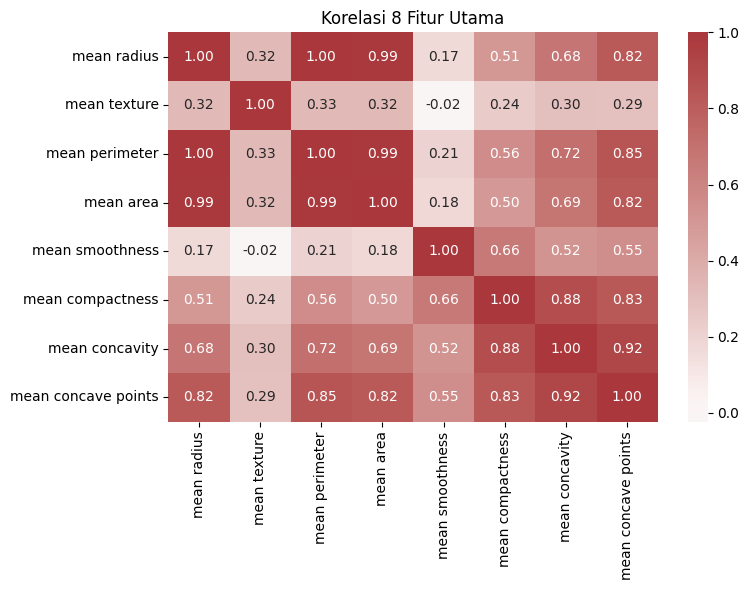

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print('Shape:', X.shape)
print('Nama kelas:', [str(n) for n in data.target_names])
print()
print('Distribusi target:')
dist = y.value_counts().rename({0: 'malignant (0)', 1: 'benign (1)'})
prop = y.value_counts(normalize=True).round(3)
print(pd.DataFrame({'jumlah': dist, 'proporsi': prop.values}))
print()
print(X.describe().T[['mean', 'std', 'min', 'max']].round(2).head(8))

# Korelasi 8 fitur pertama — cukup untuk melihat pola, tidak semua 30
korelasi = X.iloc[:, :8].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Korelasi 8 Fitur Utama')
plt.tight_layout()
plt.show()


## Langkah 2: Preprocessing

Train-test split 80:20 dengan `stratify=y` agar proporsi malignant/benign tetap. `StandardScaler` di-fit hanya pada data latih (tanpa data leakage). Scaling wajib untuk Logistic Regression; Decision Tree tidak membutuhkannya.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi malignant train:', (y_train == 0).mean().round(3))
print('Proporsi malignant test :', (y_test == 0).mean().round(3))


Train: (455, 30) | Test: (114, 30)
Proporsi malignant train: 0.374
Proporsi malignant test : 0.368


## Langkah 3: Latih Logistic Regression

Fit `LogisticRegression` pada data yang sudah distandarisasi. Koefisien diurutkan berdasarkan nilai absolut — fitur dengan |koefisien| terbesar paling berpengaruh terhadap prediksi.


In [4]:
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head(10).to_string(index=False))


               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616
      worst symmetry  -0.939181
          area error  -0.929104
     worst concavity  -0.823151
     worst perimeter  -0.763220
    worst smoothness  -0.746625


## Langkah 4: Latih Decision Tree

Fit `DecisionTreeClassifier(max_depth=4)` pada data asli (tanpa scaling). Kedalaman dibatasi agar pohon tetap dapat diinterpretasi dan tidak overfitting. Visualisasi `plot_tree()` menampilkan aturan if-else yang dipelajari model.


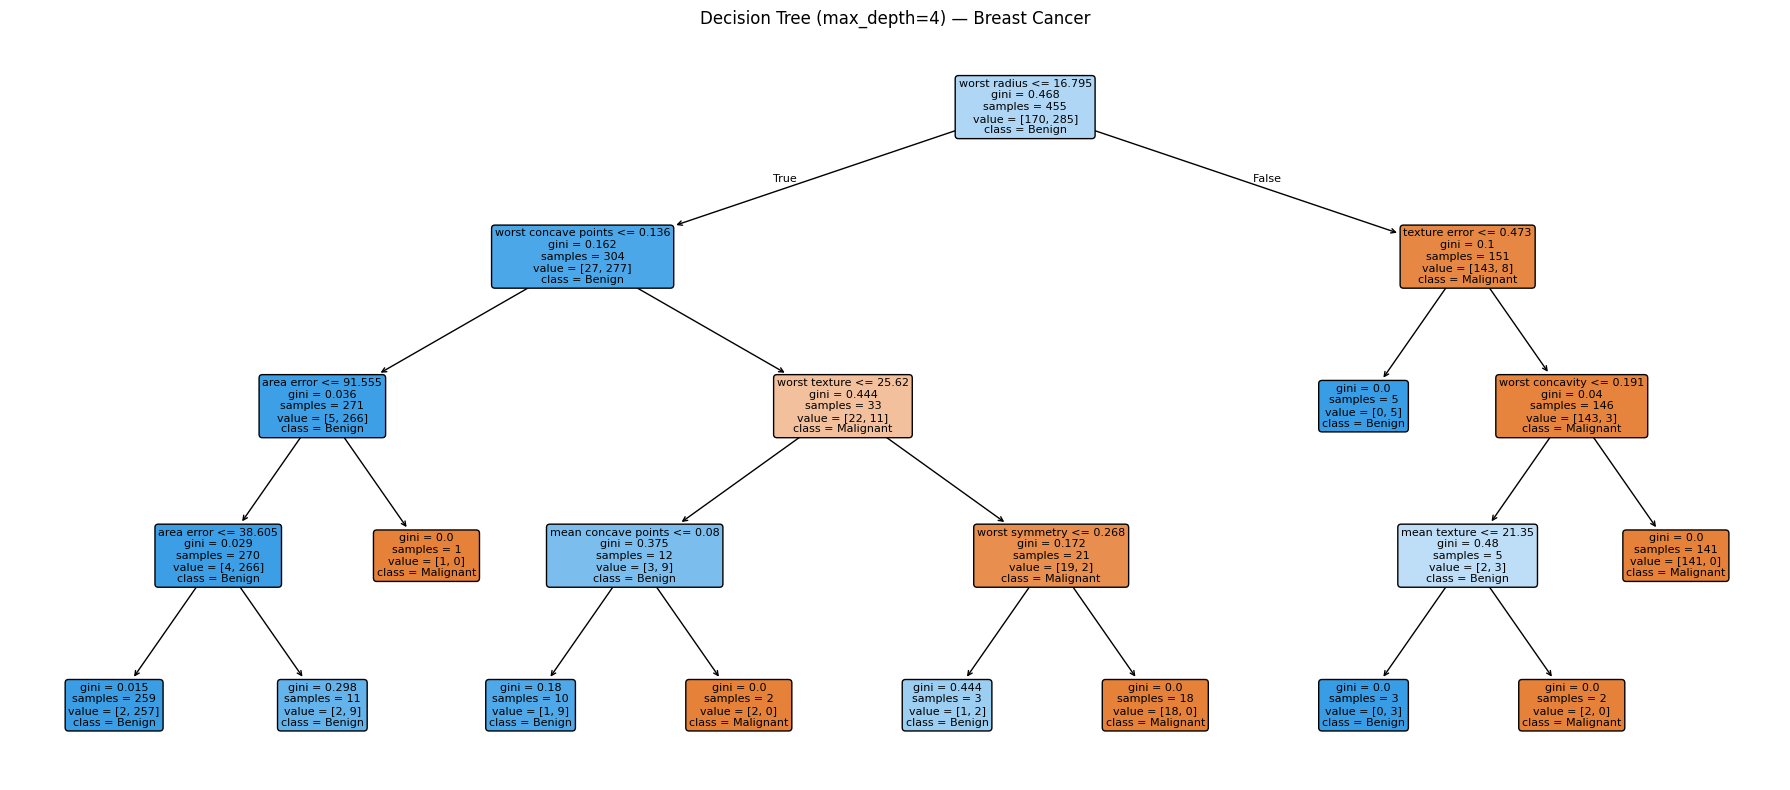

Feature importance (top 5):
               Fitur  Importance
        worst radius    0.733548
worst concave points    0.122028
       texture error    0.045785
       worst texture    0.032319
     worst concavity    0.017161


In [5]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Decision Tree (max_depth=4) — Breast Cancer')
plt.tight_layout()
plt.show()

imp = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)
print('Feature importance (top 5):')
print(imp.head().to_string(index=False))


## Langkah 5: Evaluasi & Bandingkan

Hitung Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score untuk kedua model.

**Catatan metrik:** di dataset ini `1 = benign` (jinak) dan `0 = malignant` (ganas). False Negative yang berbahaya secara medis adalah **kanker ganas yang dikira jinak**. Karena itu Precision/Recall/F1 dilaporkan untuk kelas **malignant (`pos_label=0`)**, bukan default sklearn (`pos_label=1`).


=== Logistic Regression ===
Confusion Matrix [baris=aktual, kolom=prediksi | urutan 0,1]:
[[41  1]
 [ 1 71]]
Accuracy           : 0.982
Precision (ganas)  : 0.976
Recall    (ganas)  : 0.976
F1-Score  (ganas)  : 0.976

=== Decision Tree ===
Confusion Matrix [baris=aktual, kolom=prediksi | urutan 0,1]:
[[39  3]
 [ 4 68]]
Accuracy           : 0.939
Precision (ganas)  : 0.907
Recall    (ganas)  : 0.929
F1-Score  (ganas)  : 0.918



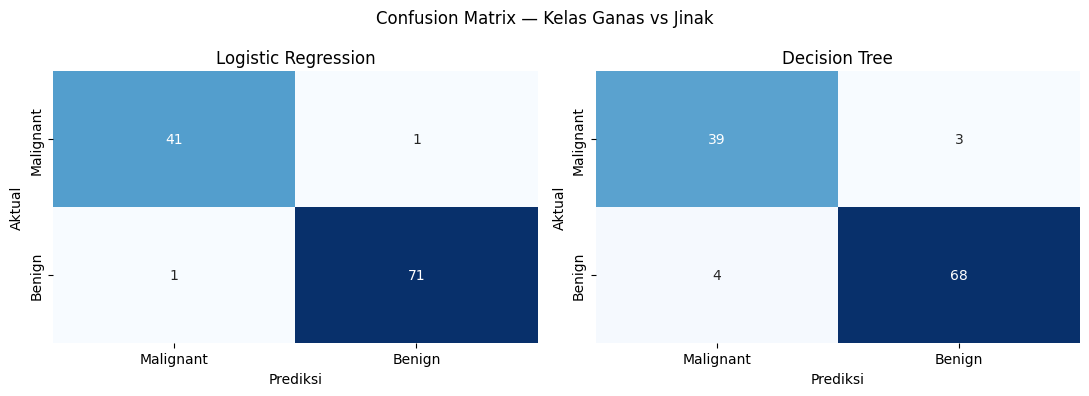

              precision    recall  f1-score   support

   malignant      0.976     0.976     0.976        42
      benign      0.986     0.986     0.986        72

    accuracy                          0.982       114
   macro avg      0.981     0.981     0.981       114
weighted avg      0.982     0.982     0.982       114



In [6]:
def evaluasi(nama, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=0)
    rec = recall_score(y_true, y_pred, pos_label=0)
    f1 = f1_score(y_true, y_pred, pos_label=0)
    print(f'=== {nama} ===')
    print('Confusion Matrix [baris=aktual, kolom=prediksi | urutan 0,1]:')
    print(cm)
    print(f'Accuracy           : {acc:.3f}')
    print(f'Precision (ganas)  : {prec:.3f}')
    print(f'Recall    (ganas)  : {rec:.3f}')
    print(f'F1-Score  (ganas)  : {f1:.3f}')
    print()
    return cm, acc, prec, rec, f1

hasil = {}
for nama, y_pred in [
    ('Logistic Regression', y_pred_log),
    ('Decision Tree', y_pred_tree),
]:
    hasil[nama] = evaluasi(nama, y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nama, (cm, *_)) in zip(axes, hasil.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
        xticklabels=['Malignant', 'Benign'],
        yticklabels=['Malignant', 'Benign']
    )
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.set_title(nama)
plt.suptitle('Confusion Matrix — Kelas Ganas vs Jinak')
plt.tight_layout()
plt.show()

print(classification_report(
    y_test, y_pred_log,
    target_names=['malignant', 'benign'], digits=3
))


### Interpretasi metrik

- **Recall kelas ganas** paling kritis: False Negative berarti pasien kanker terlewat. Accuracy semata kurang cukup karena kelas jinak lebih banyak (~63%).
- Logistic Regression unggul: Recall ganas **0.976** (1 FN) vs Decision Tree **0.929** (3 FN). Selisih 2 kasus terlewat di test set 114 baris — material untuk diagnosis.
- Trade-off yang diterima: Precision boleh sedikit lebih rendah asal Recall tetap tinggi. Di sini Logistic Regression justru lebih baik di kedua metrik.


## Kesimpulan

### Apa yang Dipelajari
- Klasifikasi memprediksi kategori diskret, berbeda dari regresi di Pertemuan 7
- Logistic Regression memakai fungsi sigmoid; Decision Tree membangun aturan if-else dengan batas kedalaman untuk menahan overfitting
- Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score — plus kapan masing-masing relevan
- Scaling dan stratified split tetap mengikuti disiplin preprocessing Pertemuan 6

### Temuan Utama
- Dataset: 569 sampel, 30 fitur, ~37% ganas / ~63% jinak
- Logistic Regression: Accuracy 0.982, Recall ganas 0.976 (CM: 1 FN, 1 FP)
- Decision Tree (`max_depth=4`): Accuracy 0.939, Recall ganas 0.929 (3 FN, 4 FP)
- Fitur paling berpengaruh di kedua model mengarah ke ukuran/tekstur sel (`worst radius`, `worst texture`, `worst concave points`)

### Keterbatasan
- Test set kecil (114 baris) — selisih 1 prediksi sudah menggeser Recall secara terlihat
- Decision Tree dibatasi `max_depth=4`; pohon lebih dalam bisa naik akurasi tapi sulit dibaca
- Belum ada ensemble (Random Forest) atau penanganan imbalance lanjutan — itu materi Pertemuan 10
